In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import scipy.sparse as sparse
from scipy.spatial.distance import pdist
import glob
import networkx as nx
from importlib import reload
from sklearn_ann.kneighbors.annoy import AnnoyTransformer

import anndata as an
import scanpy as sc

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Class build

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


input_data.shape=torch.Size([1, 100])
target_data.shape=torch.Size([1, 100])
predicted.shape=torch.Size([1, 100])


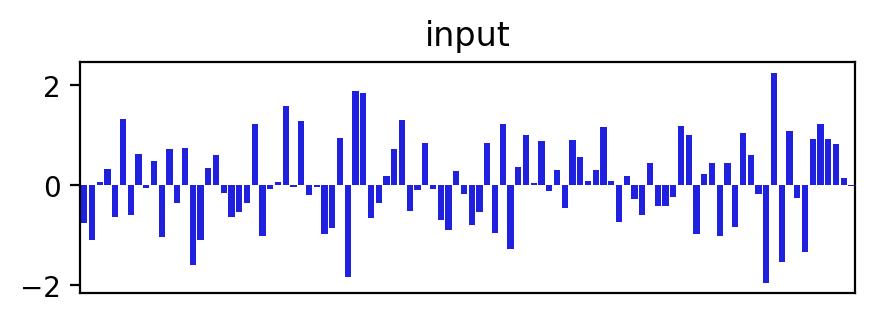

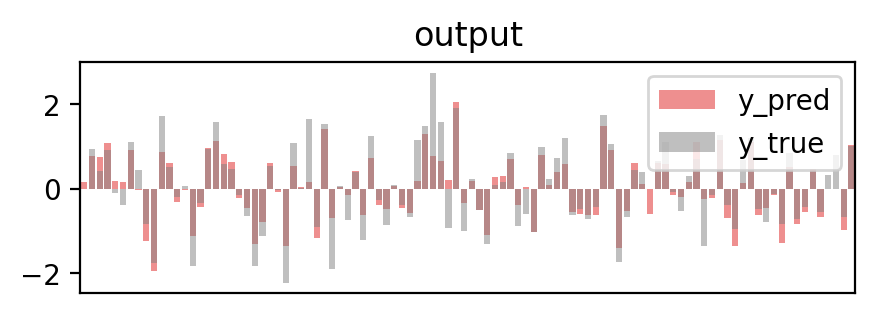

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class NextCell(nn.Module):
    def __init__(self, input_size=1000, hidden_size=128, output_size=1000, num_layers=2, num_heads=2, learning_rate=0.001):
        super(NextCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(input_size, num_heads, hidden_size),
            num_layers
        )
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x):
        """
        Predicts the next cell expression vector.

        Args:
            x (torch.Tensor): Input cell expression vector of shape [batch_size, input_size].

        Returns:
            torch.Tensor: Predicted cell expression vector of shape [batch_size, output_size].
        """
        x = x.unsqueeze(1) # Shape [batch_size, 1, input_size]
        x = x.transpose(0, 1) # Shape [1, batch_size, input_size] for transformer
        encoded = self.transformer_encoder(x) # Shape [1, batch_size, input_size]
        encoded = encoded.transpose(0, 1) # Shape [batch_size, 1, input_size]
        encoded = encoded.squeeze(1) # Shape [batch_size, input_size]

        x = self.fc1(encoded)
        x = self.relu(x)
        x = self.fc2(x)
        return x

    def train_step(self, x, y):
        """
        Performs a single training step.

        Args:
            x (torch.Tensor): Input cell expression vector of shape [batch_size, input_size].
            y (torch.Tensor): Target cell expression vector of shape [batch_size, output_size].

        Returns:
            float: Loss value.
        """
        self.optimizer.zero_grad()
        outputs = self.forward(x)
        loss = self.criterion(outputs, y)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def train_model(self, input_gene_expression, target_gene_expression, epochs=10, verbose=False):
        """
        Trains the model for a given number of epochs.

        Args:
            input_gene_expression (torch.Tensor): Input gene expression data.
            target_gene_expression (torch.Tensor): Target gene expression data.
            epochs (int): Number of training epochs.

        Returns:
            pd.DataFrame: Training loss for each epoch.
        """
        training_loss = []
        for epoch in range(epochs):
            loss = self.train_step(input_gene_expression, target_gene_expression)
            training_loss.append({'epoch': epoch + 1, 'loss': loss})
            if verbose:
                print(f'Epoch {epoch + 1}, Loss: {loss}')
        return pd.DataFrame(training_loss)

    def predict(self, input_gene_expression):
        """
        Predicts the next cell expression vector.

        Args:
            input_gene_expression (torch.Tensor): Input gene expression data.

        Returns:
            torch.Tensor: Predicted gene expression data.
        """
        self.eval()
        with torch.no_grad():
            predictions = self.forward(input_gene_expression)
        self.train()
        return predictions

    def get_embeddings(self, input_gene_expression):
        """
        Gets the embeddings from the transformer encoder.

        Args:
            input_gene_expression (torch.Tensor): Input gene expression data.

        Returns:
            torch.Tensor: Embeddings.
        """
        self.eval()
        with torch.no_grad():
            x = input_gene_expression.unsqueeze(1)
            x = x.transpose(0, 1)
            embeddings = self.transformer_encoder(x)
            embeddings = embeddings.transpose(0, 1).mean(dim=1)
        self.train()
        return embeddings

# Example usage
input_size = 100
hidden_size = 128
output_size = 100
batch_size = 1

model = NextCell(input_size, hidden_size, output_size)
input_data = torch.randn(batch_size, input_size)
target_data = torch.randn(batch_size, output_size)

print(f"{input_data.shape=}")
print(f"{target_data.shape=}")

# Training the model
training_history = model.train_model(input_data, target_data, epochs=10)
predicted = model.predict(input_data)
print(f"{predicted.shape=}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 1.5

sns.barplot(
    input_data,
    color='blue',
)
plt.xticks([])
plt.title('input')
plt.show()

sns.barplot(
    predicted.detach().numpy(),
    color='r',
    label='y_pred',
    alpha=0.5,
)

sns.barplot(
    target_data,
    color='grey',
    label='y_true',
    alpha=0.5,
)

plt.xticks([])
plt.title('output')
plt.legend()
plt.show()

# Try some real data

In [3]:
# """ CZI HSCS """
# dpath = "/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/"

# file_list = glob.glob(f"{dpath}*")
# adata = sc.read_h5ad(file_list[0])

# """ SUBSAMPLING """
# fraction = 0.25
# adata = sc.pp.sample(adata, fraction=fraction, copy=True)

# adata

In [4]:
""" TABULA SAPIENS BLOOD """
fpath = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/tabula_sapiens/extract/TS_Blood.h5ad"
adata = sc.read_h5ad(fpath)
adata.obs['cell_type'] = adata.obs['free_annotation']
adata.obs['tissue'] = adata.obs['organ_tissue']
adata.X = adata.layers['raw_counts']

""" SUBSAMPLING """
fraction = 0.25
adata = sc.pp.sample(adata, fraction=fraction, copy=True)

adata

AnnData object with n_obs × n_vars = 12528 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'cell_type', 'tissue'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs.head()

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,cell_type,tissue
cell_id,,,,,,,,,,,,,
TTTAGTCGTAGGTTTC_TSP10_Blood_NA_10X_1_1_Enriched,Blood,10X,TSP10,nan,22143.0,493,erythrocyte,erythrocyte,True,immune,male,erythrocyte,Blood
CTGAAGTTCTACTCAT_TSP14_Blood_NA_10X_1_1_5Prime,Blood,10X,TSP14,nan,7601.0,2239,classical monocyte,classical monocyte,True,immune,male,classical monocyte,Blood
TGATTCTCAGCGTGCT_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,11209.0,2823,monocyte,monocyte,True,immune,female,monocyte,Blood
CTGTAGAGTCATGCAT_TSP7_Blood_NA_10X_1_1,Blood,10X,TSP7,nan,10332.0,227,erythrocyte,erythrocyte,True,immune,female,erythrocyte,Blood
TATTGGGGTTCGGTAT_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,12005.0,3072,monocyte,monocyte,True,immune,female,monocyte,Blood


# Simple Clean-Up

In [6]:
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_counts=50)

adata.layers['raw'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

AnnData object with n_obs × n_vars = 12528 × 20214
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'cell_type', 'tissue', 'n_counts'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'umap', 'log1p'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts', 'raw'
    obsp: 'connectivities', 'distances'

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:306: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


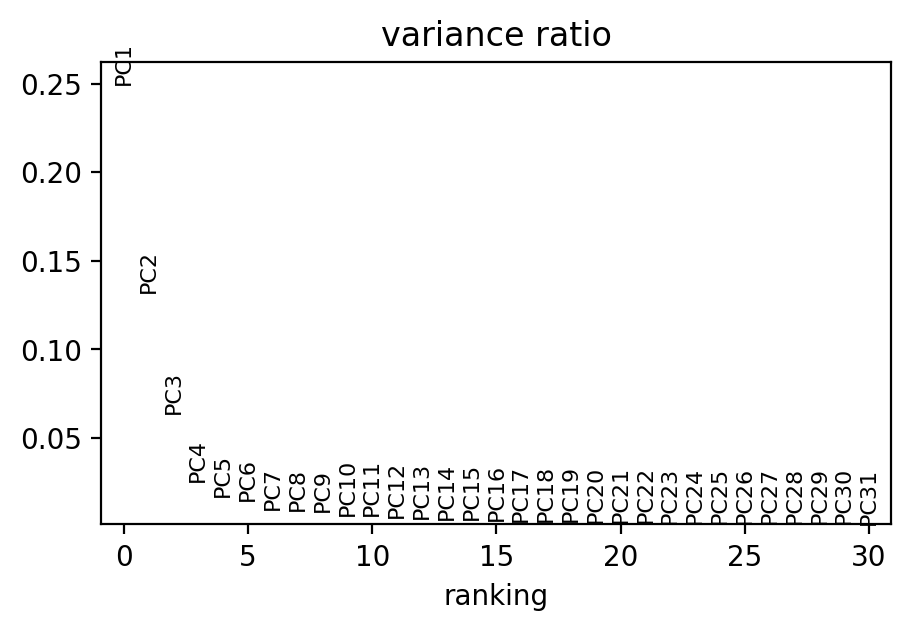

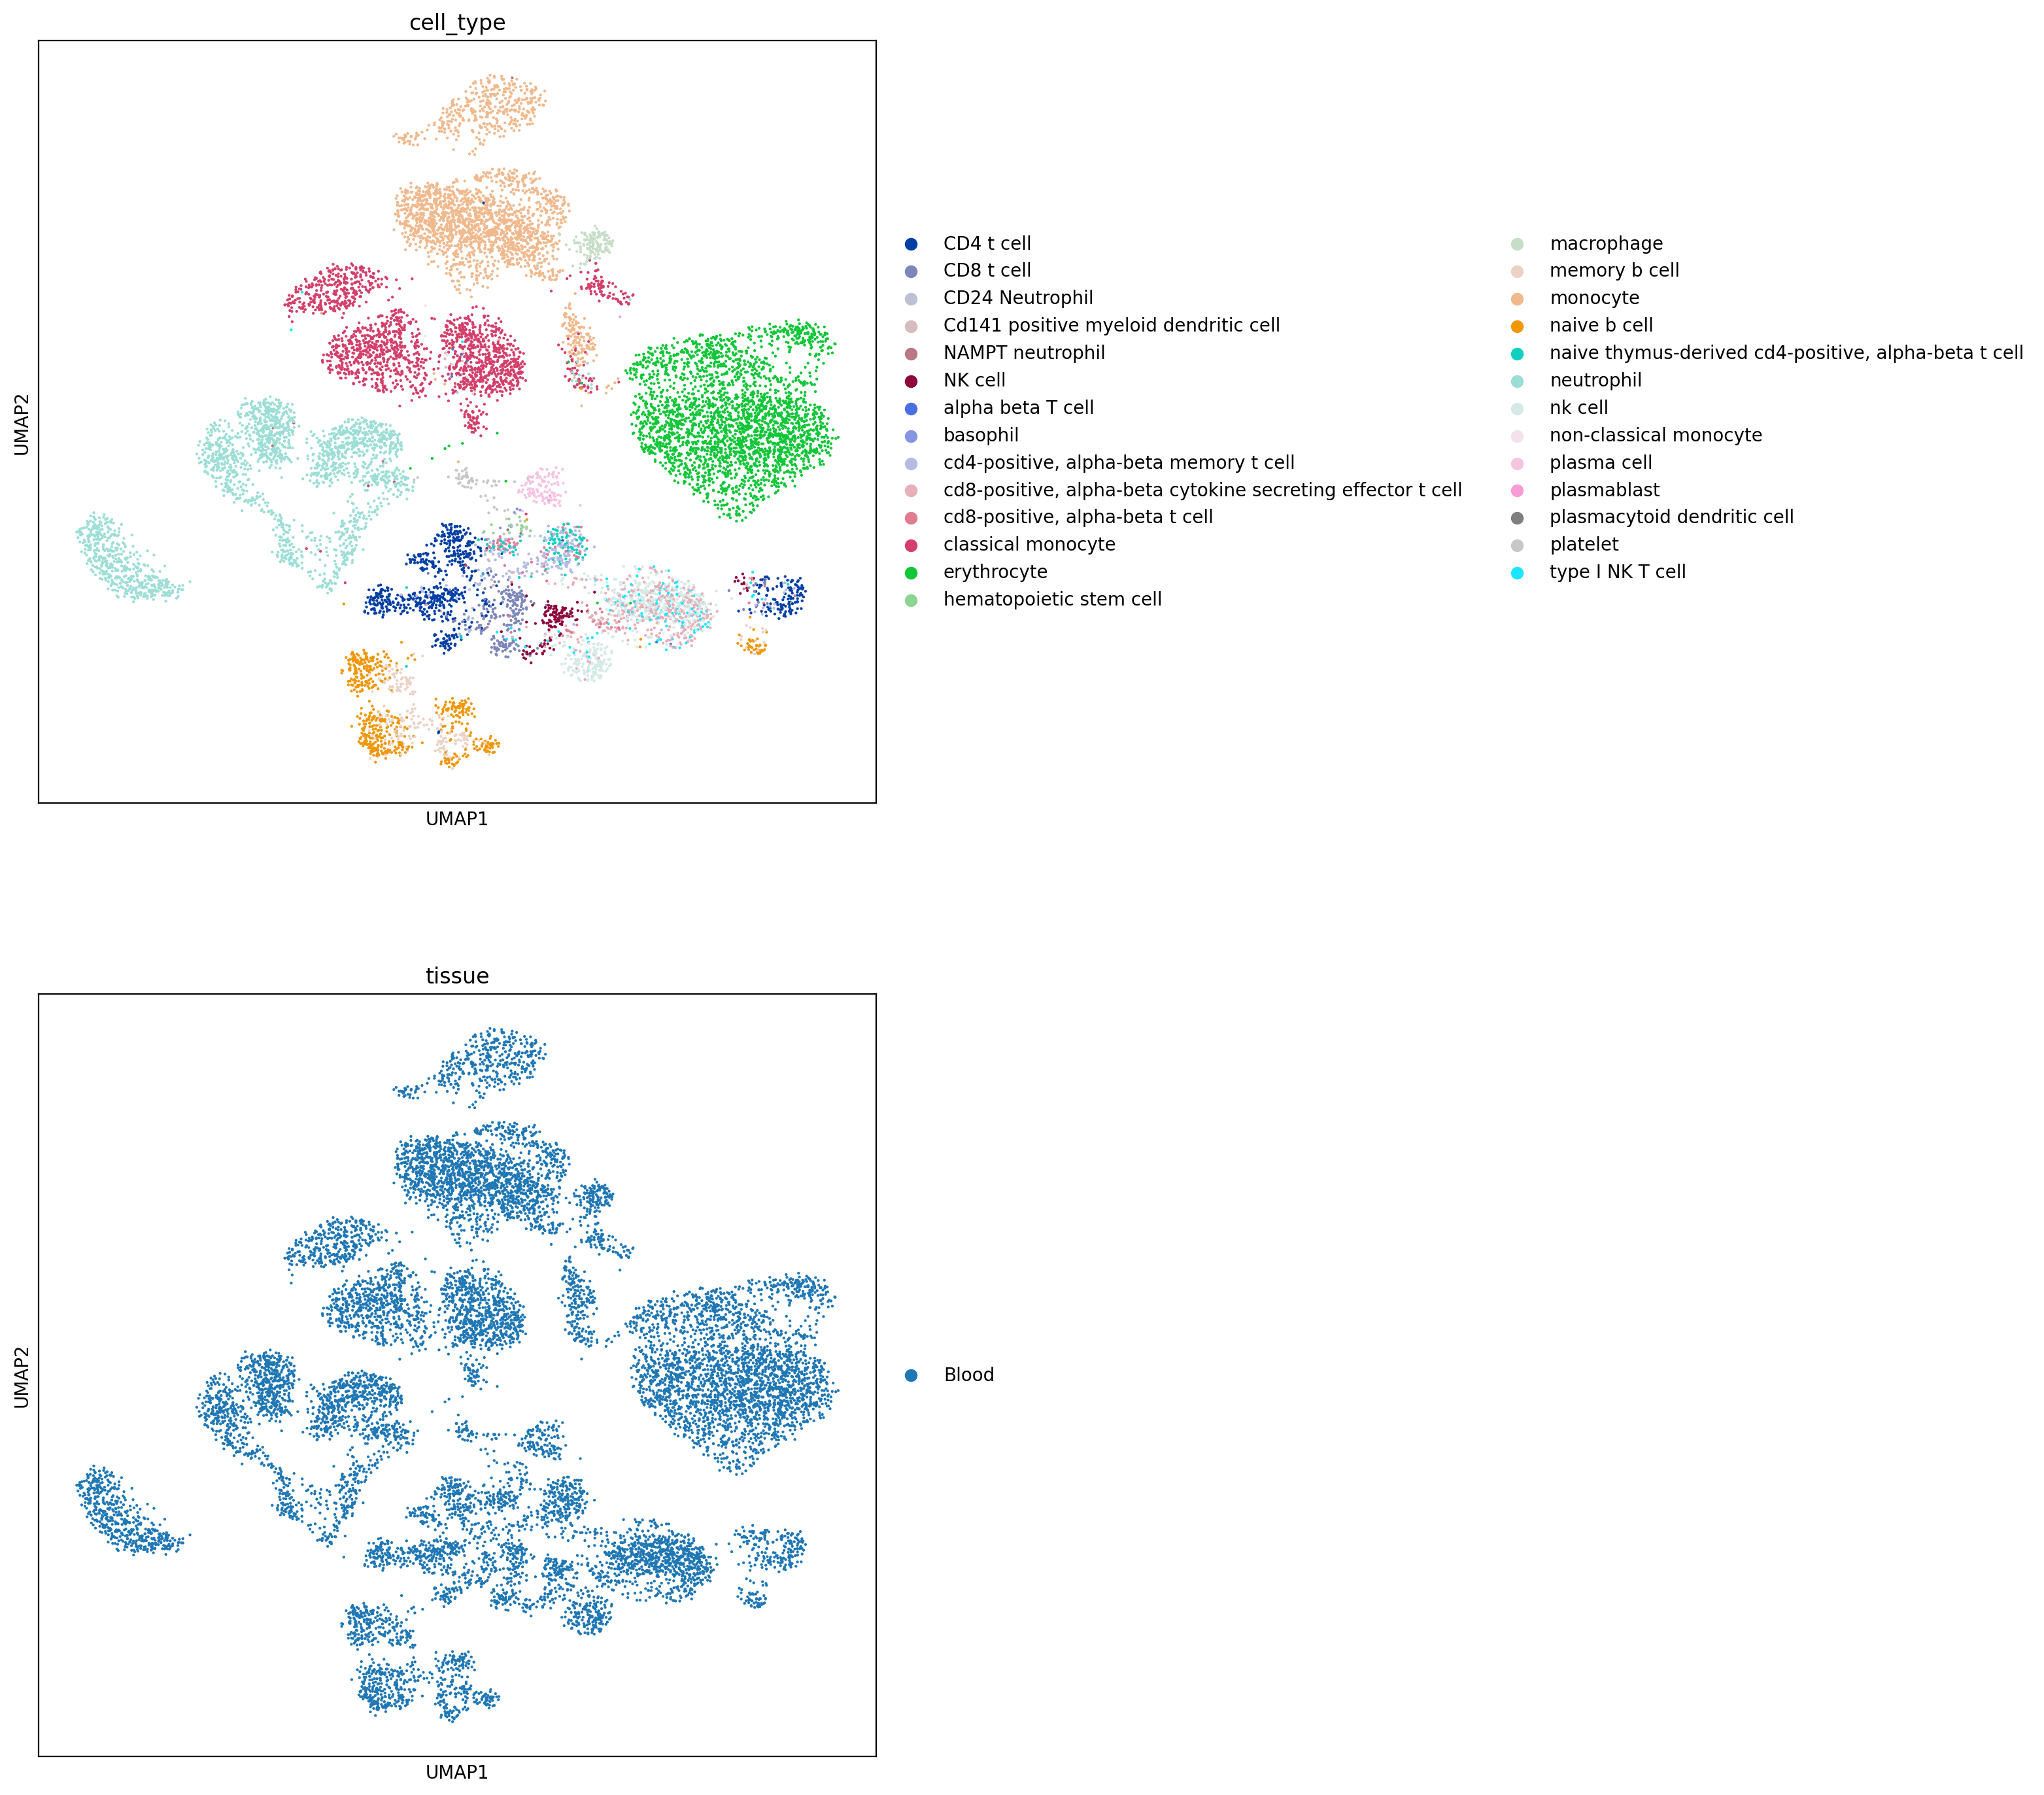

AnnData object with n_obs × n_vars = 12528 × 1500
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'cell_type', 'tissue', 'n_counts', 'UMAP 1', 'UMAP 2'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'umap', 'log1p', 'pca', 'cell_type_colors', 'tissue_colors'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    varm: 'PCs'
    layers: 'decontXcounts', 'raw_counts', 'raw'
  

In [7]:
INPUT_SIZE = 1500
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=INPUT_SIZE,
    batch_key='cell_type'
)

# ONLY keep HVGs
adata = adata[:,adata.var["highly_variable"] == True].copy()


sc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sc.pl.pca_variance_ratio(
    adata
)

sc.pp.neighbors(
    adata,
    n_neighbors=55,
)

sc.tl.umap(
    adata,
    min_dist=1.1,
)


adata.obs['UMAP 1'] = adata.obsm['X_umap'][:, 0]
adata.obs['UMAP 2'] = adata.obsm['X_umap'][:, 1]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 8

sc.pl.umap(
    adata,
    ncols=1,
    color=['cell_type', 'tissue']
)

adata

In [8]:
adata.obs['cell_type'].value_counts()

cell_type
erythrocyte                                                    2691
monocyte                                                       2241
neutrophil                                                     2106
classical monocyte                                             1783
CD4 t cell                                                      702
naive b cell                                                    571
nk cell                                                         554
cd8-positive, alpha-beta cytokine secreting effector t cell     381
CD8 t cell                                                      229
cd4-positive, alpha-beta memory t cell                          228
memory b cell                                                   228
NK cell                                                         139
macrophage                                                      130
type I NK T cell                                                121
plasma cell                           

In [9]:
class CellNet:
    """
    A class to encapsulate AnnData to NetworkX graph conversion and related operations.
    """

    def __init__(
        self, 
        adata, 
        label_column='cell_type', 
        graph_key='X_pca',
        graph_neighbors=5,
        graph_n_components=2, 
        graph_metric='euclidean',
        distance_key='X_pca',
        distance_metric='euclidean',
        distance_n_components=2,
        source_label=None,
        target_label=None,
        verbose=True
    ):
        """
        Initializes the CellNet object
        """
        self.adata = adata
        self.index = adata.obs_names
        self.label_column = label_column
        self.source_label = source_label
        self.target_label = target_label
        self.verbose = verbose
        
        self.graph_key = graph_key
        self.graph_neighbors = graph_neighbors
        self.graph_n_components = graph_n_components
        self.graph_metric = graph_metric
        self.graph = self.build_graph()

        self.distance_key = distance_key
        self.distance_metric = distance_metric
        self.distance_n_components = distance_n_components
        
    def build_graph(self):
        """
        Builds a graph from the AnnData object.
    
        Args:
            verbose (bool, optional): If True, prints timing information. Defaults to False.
        """
        start_time = time.time()
    
        sc.pp.neighbors(
            self.adata,
            n_neighbors=self.graph_neighbors,
            use_rep=self.graph_key,
            n_pcs=self.graph_n_components,
            metric=self.graph_metric,
        )
    
        neighbors_time = time.time()
        if self.verbose:
            print(f"Neighbors calculation time: {neighbors_time - start_time:.4f} seconds")
    
        G = nx.from_scipy_sparse_array(
            self.adata.obsp['connectivities'],
        )
    
        graph_time = time.time()
        if self.verbose:
            print(f"Graph creation time: {graph_time - neighbors_time:.4f} seconds")
    
        # relabel nodes
        node_mapping = {i: self.index[i] for i in range(len(self.index))}
        G = nx.relabel_nodes(G, node_mapping)
        
        if self.verbose:
            print(G)
            print(f"Graph built.\n")

        return G

    def _random_source(self):
        if self.source_label is None:
            raise ValueError('CellNet.source_label cannot be `None`. Please set a source_label.')
            
        return random.choice(
            self.adata.obs[self.adata.obs[self.label_column] == self.source_label].index
        )

    def _random_target(self):
        if self.target_label is None:
            raise ValueError('CellNet.target_label cannot be `None`. Please set a target_label.')
            
        return random.choice(
            self.adata.obs[self.adata.obs[self.label_column] == self.target_label].index
        )
    

    def get_random_nodes(self, source_type, target_type):
        """
        Selects a random source node and a random target node from the AnnData object.
        """
        source_node = random.choice(self.adata.obs[self.adata.obs[self.annotation_col] == source_type].index)
        target_node = random.choice(self.adata.obs[self.adata.obs[self.annotation_col] == target_type].index)
        return source_node, target_node
    
    def _distance(self, node_i, node_j):
        """
        Computes the hueristic distance between two nodes.
        """
        i = self.index.get_loc(node_i)
        j = self.index.get_loc(node_j)
        key = self.distance_key
        X = self.adata[[i, j], :].obsm[key]
        return float(pdist(X, metric=self.distance_metric)[0])


    def _find_path(self, source_node=None, target_node=None):
        path = nx.astar_path(
            self.graph,
            source_node,
            target_node,
            heuristic=lambda u, v: self._distance(u, v)
        )
        return path
    
    def get_random_paths(self, n_paths=1):
        """A function to generate n random paths between source and target types,
        with optional timing print statements.
        """
    
        paths = []
    
        for i in range(n_paths):
            start_time = time.time()  
            path = self._find_path(
                self._random_source(),
                self._random_target(),
            )
            end_time = time.time()  
            elapsed_time = end_time - start_time
    
            if self.verbose:
                print(f"Path {i+1} ({len(path)} nodes) generated in {elapsed_time:.4f} seconds.")
    
            paths.append(path) 
        return paths
            
        

    
cn = CellNet(
    adata=adata,
    label_column='cell_type',
    source_label='hematopoietic stem cell',
    target_label='macrophage',
    distance_metric='cosine',
    graph_neighbors=35,
    verbose=True,
)

paths = cn.get_random_paths(n_paths=2)
paths[0]

Neighbors calculation time: 2.9641 seconds
Graph creation time: 0.5969 seconds
Graph with 12528 nodes and 244743 edges
Graph built.

Path 1 (46 nodes) generated in 7.5681 seconds.
Path 2 (16 nodes) generated in 2.7864 seconds.


['CCGTAGGCAGGAGGTT_TSP7_Blood_NA_10X_1_1',
 'ATCGTGAGTTCTTGTT_TSP7_Blood_NA_10X_2_1',
 'CCACACTTCCTAGCGG_TSP14_Blood_NA_10X_3_1',
 'TGTTGAGTCGATCCAA_TSP7_Blood_NA_10X_2_1',
 'B107925_O10_S288.homo.gencode.v30.ERCC.chrM',
 'GTGTTAGGTCCGAATT_TSP2_Blood_NA_10X_1_4_5prime',
 'GTTGCTCCAGCAGATG_TSP2_Blood_NA_10X_1_3',
 'GAGGGATCATATGGCT_TSP10_Blood_NA_10X_1_1_Enriched',
 'TAGTGCATCACCTTGC_TSP10_Blood_NA_10X_1_1_Enriched',
 'ATAGAGAAGATTGGGC_TSP2_Blood_NA_10X_2_1',
 'TCTGTCGGTCATTGCA_TSP10_Blood_NA_10X_2_1_Whole',
 'ATCCCTGTCTTGGTGA_TSP1_blood_3',
 'CTGAGGCTCTATACGG_TSP10_Blood_NA_10X_1_1_Whole',
 'ATATCCTGTAACGGTG_TSP10_Blood_NA_10X_1_1_Enriched',
 'GGGTGAACAACTACGT_TSP10_Blood_NA_10X_1_1_Whole',
 'CATTTCAGTATTGGCT_TSP10_Blood_NA_10X_2_1_Whole',
 'TAATTCCGTACTGAGG_TSP10_Blood_NA_10X_1_1_Enriched',
 'TCGGGCATCCCTCTTT_TSP2_Blood_NA_10X_1_1_SheelaPrep',
 'CAATCGAAGCGCTGCT_TSP1_blood_1',
 'CAGGGCTGTAGACAAT_TSP1_blood_3',
 'AAAGTGAGTCATAGTC_TSP2_Blood_NA_10X_1_3',
 'GATTCGAGTACTCAAC_TSP1_blood_3'

,cell_type,step
cell_id,,
CCGTAGGCAGGAGGTT_TSP7_Blood_NA_10X_1_1,hematopoietic stem cell,1
ATCGTGAGTTCTTGTT_TSP7_Blood_NA_10X_2_1,plasma cell,2
CCACACTTCCTAGCGG_TSP14_Blood_NA_10X_3_1,basophil,3
TGTTGAGTCGATCCAA_TSP7_Blood_NA_10X_2_1,hematopoietic stem cell,4
B107925_O10_S288.homo.gencode.v30.ERCC.chrM,CD4 t cell,5
GTGTTAGGTCCGAATT_TSP2_Blood_NA_10X_1_4_5prime,CD4 t cell,6
GTTGCTCCAGCAGATG_TSP2_Blood_NA_10X_1_3,CD4 t cell,7
GAGGGATCATATGGCT_TSP10_Blood_NA_10X_1_1_Enriched,memory b cell,8
TAGTGCATCACCTTGC_TSP10_Blood_NA_10X_1_1_Enriched,memory b cell,9


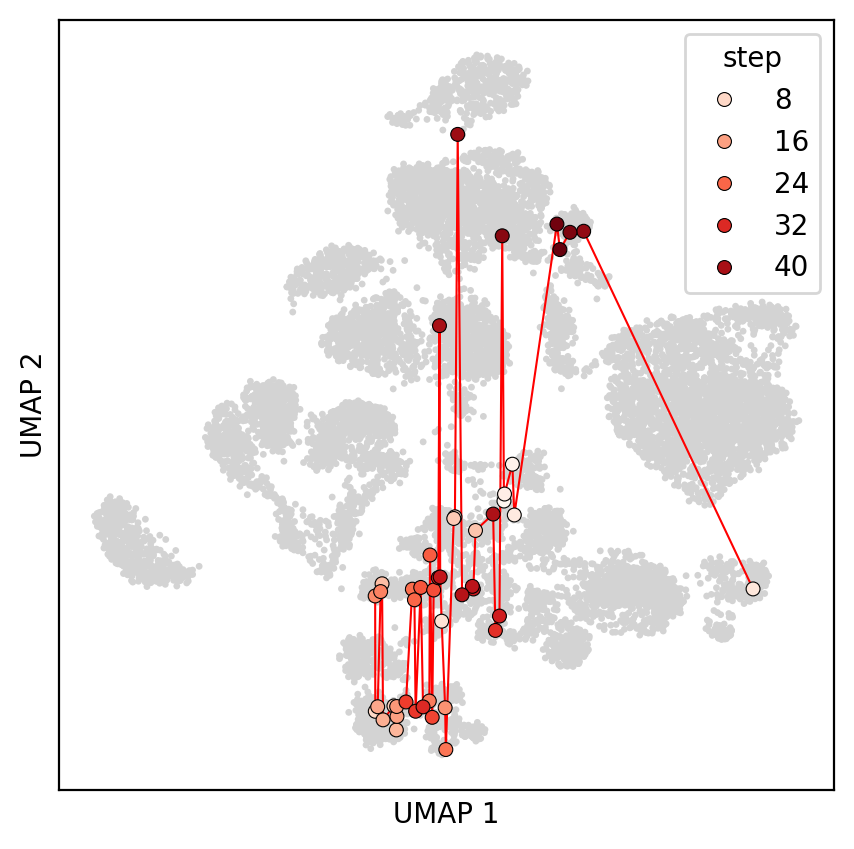

In [10]:
# extrtact and plot a single "trajectory"
traj = adata[paths[0], :].copy()
traj.obs['step'] = range(1, len(paths[0]) + 1 )


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    x=adata.obsm['X_umap'][:, 0],
    y=adata.obsm['X_umap'][:, 1],
    s=6,
    c='lightgrey',
    ec='none',
)

sns.scatterplot(
    data=traj.obs,
    x='UMAP 1',
    y='UMAP 2',
    s=25,
    hue='step',
    palette='Reds',
    ec='k',
    zorder=5,
)

sns.lineplot(
    data=traj.obs,
    x='UMAP 1',
    y='UMAP 2',
    c='r',
    lw=0.75,
    legend=False,
    zorder=2,
    marker=None,
    markeredgecolor='none',
)
plt.xticks([])
plt.yticks([])

traj.obs[['cell_type', 'step']]

In [11]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Build trainning data

In [ ]:
steps

In [ ]:
x_idx = list(steps.values())[:-1]
y_idx = list(steps.values())[1:]

X = traj.X[x_idx, :].todense().copy()
Y = traj.X[y_idx, :].todense().copy()

print(f"{X.shape=} {type(X)}")
print(f"{Y.shape=} {type(Y)}")

traj

# Train

In [ ]:
# Example usage:
input_size = traj.shape[1]
hidden_size = 128
output_size = traj.shape[1]

model = NextCell(input_size, hidden_size, output_size)

# Example data (replace with your actual data)
input_gene_expression = torch.tensor(X)
target_gene_expression = torch.tensor(Y)

loss = model.train_model(input_gene_expression, target_gene_expression, epochs=250)

# Example prediction:
prediction = model.predict(input_gene_expression)
print("Prediction shape:", prediction.shape)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.lineplot(
    data=loss,
    x='epoch',
    y='loss',
)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 25, 2

inputs = traj.to_df()

sns.heatmap(
    inputs
)
plt.yticks([])
plt.title('input expression')
plt.xlabel('')
plt.show()

sns.heatmap(
    pd.DataFrame(
        prediction, 
        columns=inputs.columns,
    )
)
plt.yticks([])
plt.xlabel('')
plt.title('predicted expression')
plt.show()

# Embeddings

In [ ]:
adata.var.head()

In [ ]:
emb = model.get_embeddings(input_gene_expression)
print(f"{emb.shape=}")

edata = an.AnnData(
    emb.detach().numpy().T, 
    obs=adata.var,
)

edata.obs['gene_name'] = edata.obs_names

sc.pp.neighbors(
    edata,
    n_neighbors=3,
)

sc.tl.umap(
    edata,
    min_dist=0.15,
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    edata,
    ncols=1,
    color='means',
)

edata

# Larger Example

In [ ]:
def sample_pairs_arrays(numbers, n):
    """
    Samples n pairs (i, j) randomly from a list of integers, where i < j,
    and returns two NumPy arrays, one with i values and one with j values.

    Args:
        numbers (list of int): List of integers to sample from.
        n (int): Number of pairs to sample.

    Returns:
        tuple of numpy.ndarray: Two NumPy arrays, one with i values and one with j values.
    """
    num_numbers = len(numbers)
    i_indices = np.random.choice(num_numbers, size=n)
    j_indices = np.random.choice(num_numbers, size=n)

    i_values = np.array(numbers)[i_indices]
    j_values = np.array(numbers)[j_indices]

    # Ensure i < j
    mask = i_values >= j_values
    while np.any(mask):
        j_values[mask] = np.array(numbers)[np.random.choice(num_numbers, size=np.sum(mask))]
        mask = i_values >= j_values

    return i_values, j_values

In [ ]:
n_paths = 25
sample_factor = 3 # from each path

X = []
Y = []

for i in range(n_paths):
    # Find a path between cell types 'A' and 'B'
    start_time = time.time()
    path = network.a_star(
        source_type=source_type,
        target_type=target_type,
    )
    end_time = time.time()

    steps = {k: i for i, k in enumerate(path)}
    idx_list = list(steps.values())

    # PAIR RANDOM CELLS FROM THE SAME PATH
    x_idx, y_idx = sample_pairs_arrays(idx_list, int(sample_factor*len(path)))
    print(f"Path {i + 1} (len={len(path)}): Pathfinding took: {end_time - start_time:.4f} seconds")

    # subset trajectories
    x_traj = adata.X[x_idx, :].todense().copy()
    y_traj = adata.X[y_idx, :].todense().copy()

    print(f"{x_traj.shape=} {type(x_traj)} {y_traj.shape=} {type(y_traj)}")
    X.append(x_traj)
    Y.append(y_traj)
    # break

X = np.vstack(X)
Y = np.vstack(Y)
print(f"{X.shape=}")
print(f"{Y.shape=}")

In [ ]:
input_size = traj.shape[1]
hidden_size = 128
output_size = traj.shape[1]

model = NextCell(input_size, hidden_size, output_size)

# Example data (replace with your actual data)
input_gene_expression = torch.tensor(X)
target_gene_expression = torch.tensor(Y)

print(f"{input_gene_expression.shape=}")
print(f"{target_gene_expression.shape=}")

loss = model.train_model(input_gene_expression, target_gene_expression, epochs=1000)

# Example prediction:
prediction = model.predict(input_gene_expression)
print("Prediction shape:", prediction.shape)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.lineplot(
    data=loss,
    x='epoch',
    y='loss',
)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 4

input_df =  pd.DataFrame(
        input_gene_expression, 
        columns=adata.var_names,
    )

pred_df =  pd.DataFrame(
        prediction, 
        columns=adata.var_names,
    )

sample_cols = np.random.choice(adata.var_names, 25, replace=False)

sns.heatmap(
   input_df[sample_cols]
)
plt.yticks([])
plt.title('input expression')
plt.xlabel('')
plt.show()

sns.heatmap(
   pred_df[sample_cols]
)
plt.yticks([])
plt.xlabel('')
plt.title('predicted expression')
plt.show()

In [ ]:
tf_list_path = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/scenic/tf_lists/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(tf_list_path)]
print(f"{len(tf_list)=}")
tf_list[:20]

In [ ]:
emb = model.get_embeddings(input_gene_expression)
print(f"{emb.shape=}")

edata = an.AnnData(
    emb.detach().numpy().T, 
    obs=adata.var,
)

edata.obs['gene_name'] = edata.obs_names
edata.obs['is_tf'] = edata.obs['gene_name'].isin(tf_list)

sc.pp.neighbors(
    edata,
)

sc.tl.umap(
    edata,
    min_dist=0.15,
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    edata,
    ncols=1,
    color=['means', 'is_tf'],
)

edata

In [ ]:
break

In [ ]:
break

In [ ]:
adata.obs['cell_type'].value_counts()

In [ ]:
break

In [ ]:
def anndata_to_networkx(adata):
  """
  Converts an AnnData object with precomputed connectivities and distances 
  to a networkX graph. Adds all entries in adata.obs as node attributes.

  Args:
    adata: An AnnData object with 'connectivities' and 'distances' in obsp.

  Returns:
    A networkX graph object.
  """
  graph = nx.Graph()
  
  # Add nodes with attributes from adata.obs
  for i, cell_name in enumerate(adata.obs_names):
    graph.add_node(cell_name, **adata.obs.iloc[i].to_dict())

  # Add edges based on connectivities
  rows, cols = adata.obsp['connectivities'].nonzero()
  for i, j in zip(rows, cols):
    if i < j:  # Avoid adding duplicate edges
      weight = adata.obsp['distances'][i, j]
      graph.add_edge(adata.obs_names[i], adata.obs_names[j], weight=weight)

  return graph


def get_random_nodes(adata, source_type, target_type):
  """
  Selects a random source node and a random target node from an AnnData object.
  """
  source_node = random.choice(adata.obs[adata.obs['free_annotation'] == source_type].index)
  target_node = random.choice(adata.obs[adata.obs['free_annotation'] == target_type].index)
  return source_node, target_node


def compute_distance(source_node, target_node, obsm_key='X_pca'):
    """ The Euclidean distance between the two points.
    """
    source_coords = adata[source_node, :].obsm[obsm_key]
    target_coords = adata[target_node, :].obsm[obsm_key]
    distance = np.linalg.norm(source_coords - target_coords)
    return distance



path = nx.astar_path(
    G, 
    source_node, 
    target_node,
    heuristic=compute_distance,
)



source_type = "hematopoietic stem cell"
target_type = "macrophage"
obsm_key = 'X_pca'

source_node, target_node = get_random_nodes(
    adata, 
    source_type,
    target_type,
)

